In [31]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

In [32]:
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (12, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
BLUE  = "#1565C0"
RED   = "#D32F2F"
GREEN = "#388E3C"
AMBER = "#F57F17"

In [33]:
df = pd.read_csv("../data/raw/hotel_bookings.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Shape: (119390, 32)
Columns: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']


In [34]:
print("=" * 10)
print("DATASET OVERVIEW")
print("=" * 10)
print(df.dtypes.value_counts())
print(f"Date range: {df['arrival_date_year'].min()} – {df['arrival_date_year'].max()}")
print(f"\nHotels:\n{df['hotel'].value_counts()}")
print(f"\nCancellation rate: {df['is_canceled'].mean()*100:.1f}%")
print(f"\nADR  mean: {df['adr'].mean():.1f} EUR | std: {df['adr'].std():.1f} | "
      f"min: {df['adr'].min():.1f} | max: {df['adr'].max():.1f}")

DATASET OVERVIEW
int64      16
object     12
float64     4
Name: count, dtype: int64
Date range: 2015 – 2017

Hotels:
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

Cancellation rate: 37.0%

ADR  mean: 101.8 EUR | std: 50.5 | min: -6.4 | max: 5400.0


In [35]:
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

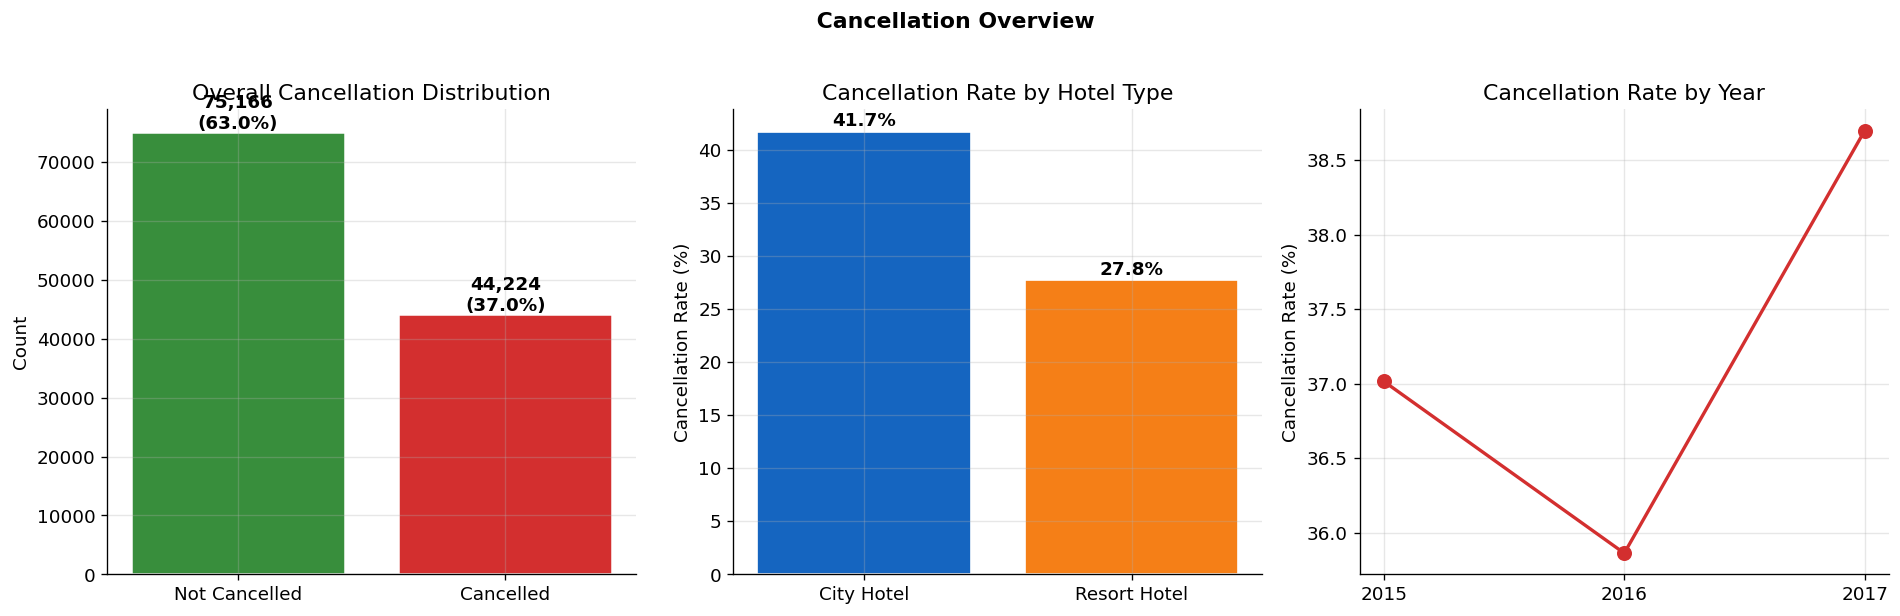

In [36]:
# Cancellation Rate Overview
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Overall cancel rate
cancel_counts = df["is_canceled"].value_counts()
axes[0].bar(["Not Cancelled", "Cancelled"], cancel_counts.values,
            color=[GREEN, RED], edgecolor="white", linewidth=1.5)
axes[0].set_title("Overall Cancellation Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(cancel_counts.values):
    axes[0].text(i, v + 500, f"{v:,}\n({v/len(df)*100:.1f}%)",
                 ha="center", fontweight="bold")

# By hotel type
cancel_by_hotel = df.groupby("hotel")["is_canceled"].mean() * 100
axes[1].bar(cancel_by_hotel.index, cancel_by_hotel.values,
            color=[BLUE, AMBER], edgecolor="white")
axes[1].set_title("Cancellation Rate by Hotel Type")
axes[1].set_ylabel("Cancellation Rate (%)")
for i, v in enumerate(cancel_by_hotel.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

# By year
cancel_by_year = df.groupby("arrival_date_year")["is_canceled"].mean() * 100
axes[2].plot(cancel_by_year.index, cancel_by_year.values,
             marker="o", color=RED, lw=2, ms=8)
axes[2].set_title("Cancellation Rate by Year")
axes[2].set_ylabel("Cancellation Rate (%)")
axes[2].set_xticks(cancel_by_year.index)

plt.suptitle(" Cancellation Overview", fontweight="bold", y=1.02)
plt.tight_layout()



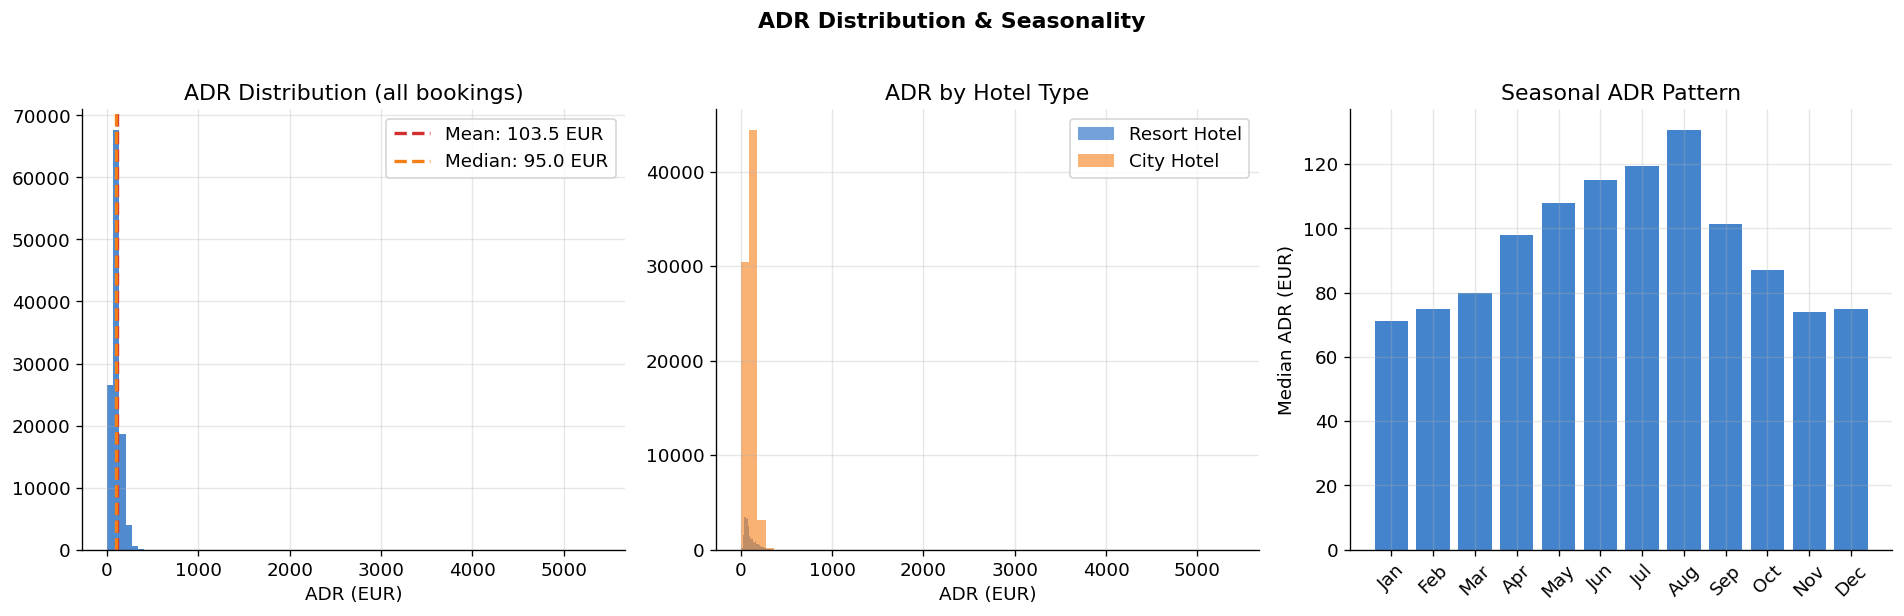

In [37]:
# ADR Distribution

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Overall ADR distribution
df_clean_adr = df[df["adr"] > 0]
axes[0].hist(df_clean_adr["adr"], bins=80, color=BLUE, alpha=0.75, edgecolor="none")
axes[0].axvline(df_clean_adr["adr"].mean(), color=RED, lw=2, linestyle="--",
                label=f"Mean: {df_clean_adr['adr'].mean():.1f} EUR")
axes[0].axvline(df_clean_adr["adr"].median(), color=AMBER, lw=2, linestyle="--",
                label=f"Median: {df_clean_adr['adr'].median():.1f} EUR")
axes[0].set_xlabel("ADR (EUR)")
axes[0].set_title("ADR Distribution (all bookings)")
axes[0].legend()

# ADR by hotel
for i, hotel in enumerate(df["hotel"].unique()):
    sub = df[df["hotel"] == hotel]["adr"]
    axes[1].hist(sub[sub > 0], bins=60, alpha=0.6, label=hotel,
                 color=[BLUE, AMBER][i])
axes[1].set_xlabel("ADR (EUR)")
axes[1].set_title("ADR by Hotel Type")
axes[1].legend()

# ADR by month
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
adr_by_month = (df[df["adr"] > 0]
                .groupby("arrival_date_month")["adr"]
                .median()
                .reindex(month_order))
axes[2].bar(range(12), adr_by_month.values, color=BLUE, alpha=0.8)
axes[2].set_xticks(range(12))
axes[2].set_xticklabels([m[:3] for m in month_order], rotation=45)
axes[2].set_ylabel("Median ADR (EUR)")
axes[2].set_title("Seasonal ADR Pattern")

plt.suptitle("ADR Distribution & Seasonality", fontweight="bold", y=1.02)
plt.tight_layout()


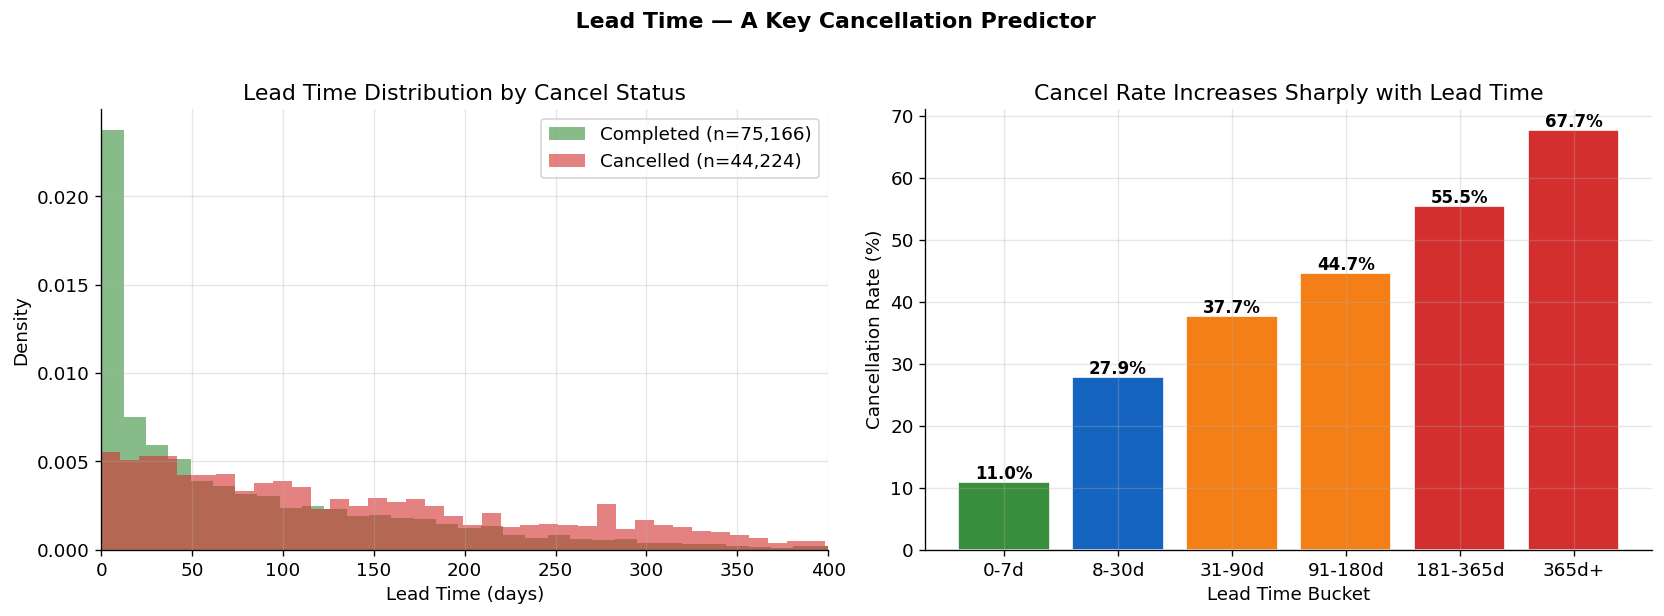

In [38]:
# Lead Time Analysis

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lead time distribution by cancel status
for label, color in [(0, GREEN), (1, RED)]:
    subset = df[df["is_canceled"] == label]["lead_time"]
    axes[0].hist(subset, bins=60, alpha=0.6,
                 label=f"{'Cancelled' if label else 'Completed'} (n={len(subset):,})",
                 color=color, density=True)
axes[0].set_xlabel("Lead Time (days)")
axes[0].set_ylabel("Density")
axes[0].set_title("Lead Time Distribution by Cancel Status")
axes[0].legend()
axes[0].set_xlim(0, 400)

# Average cancel rate by lead time bucket
df["lead_bucket"] = pd.cut(df["lead_time"],
    bins=[0, 7, 30, 90, 180, 365, 999],
    labels=["0-7d", "8-30d", "31-90d", "91-180d", "181-365d", "365d+"])
cancel_by_lead = df.groupby("lead_bucket")["is_canceled"].mean() * 100
axes[1].bar(cancel_by_lead.index, cancel_by_lead.values,
            color=[GREEN, BLUE, AMBER, AMBER, RED, RED], edgecolor="white")
axes[1].set_xlabel("Lead Time Bucket")
axes[1].set_ylabel("Cancellation Rate (%)")
axes[1].set_title("Cancel Rate Increases Sharply with Lead Time")
for i, v in enumerate(cancel_by_lead.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold", fontsize=10)

plt.suptitle(" Lead Time — A Key Cancellation Predictor", fontweight="bold", y=1.02)
plt.tight_layout()

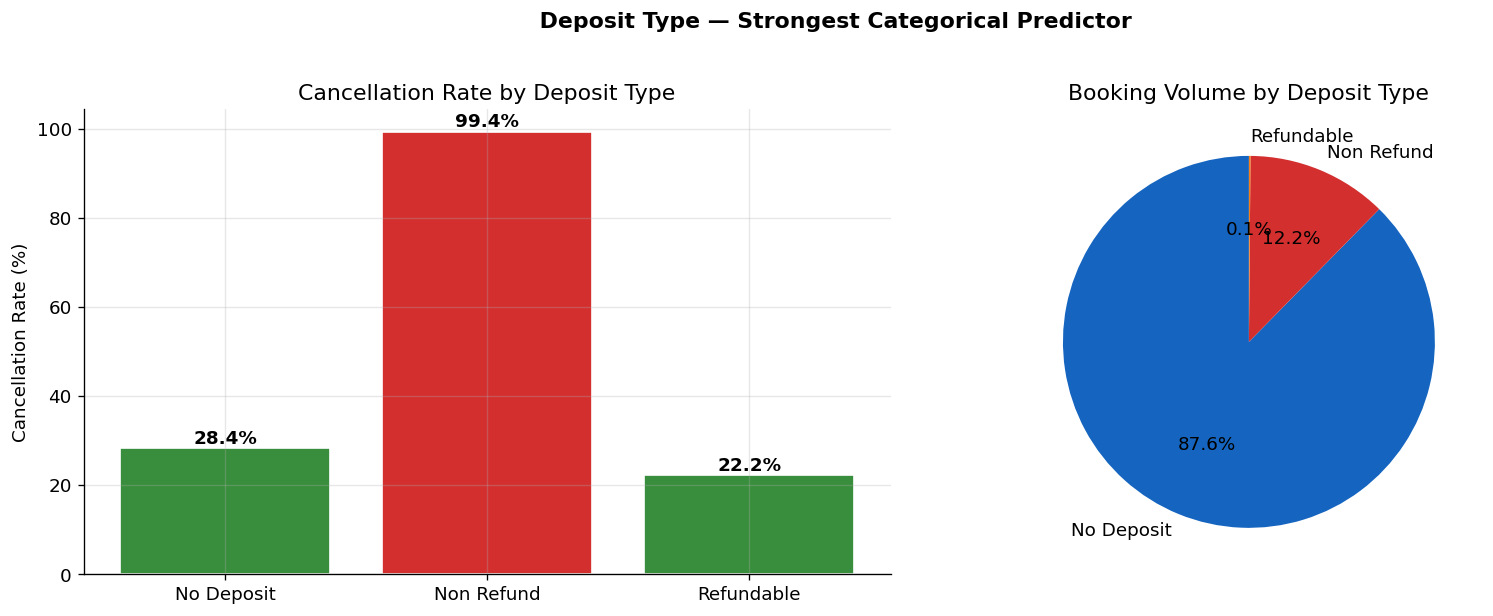

In [39]:

# Deposit Type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cancel_by_deposit = df.groupby("deposit_type")["is_canceled"].mean() * 100
bar_colors = [RED if v > 40 else GREEN for v in cancel_by_deposit.values]
axes[0].bar(cancel_by_deposit.index, cancel_by_deposit.values,
            color=bar_colors, edgecolor="white")
axes[0].set_ylabel("Cancellation Rate (%)")
axes[0].set_title("Cancellation Rate by Deposit Type")
for i, v in enumerate(cancel_by_deposit.values):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

# Volume
deposit_counts = df["deposit_type"].value_counts()
axes[1].pie(deposit_counts.values, labels=deposit_counts.index,
            autopct="%1.1f%%", colors=[BLUE, RED, AMBER], startangle=90)
axes[1].set_title("Booking Volume by Deposit Type")

plt.suptitle(" Deposit Type — Strongest Categorical Predictor", fontweight="bold", y=1.02)
plt.tight_layout()




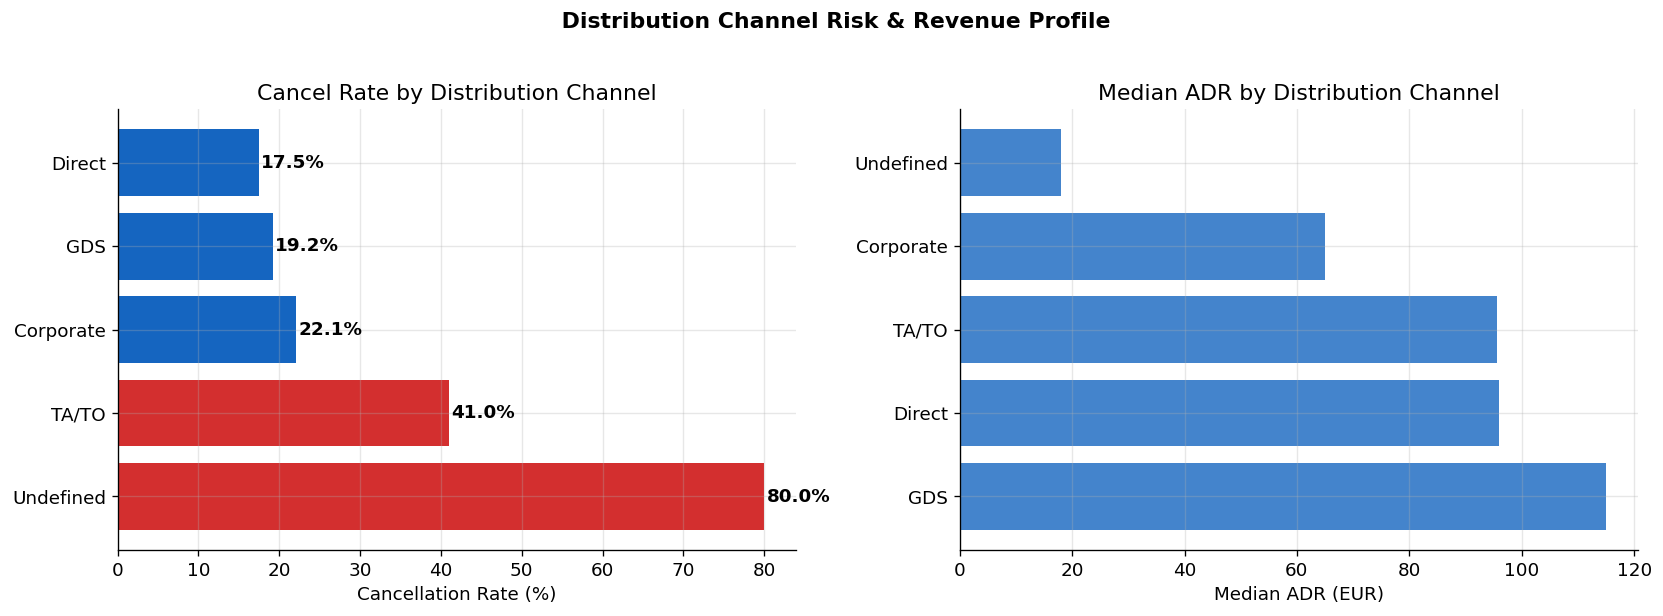

In [40]:
# Distribution Channel
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cancel_by_channel = df.groupby("distribution_channel")["is_canceled"].mean() * 100
cancel_by_channel = cancel_by_channel.sort_values(ascending=False)
axes[0].barh(cancel_by_channel.index, cancel_by_channel.values,
             color=[RED if v > 35 else BLUE for v in cancel_by_channel.values])
axes[0].set_xlabel("Cancellation Rate (%)")
axes[0].set_title("Cancel Rate by Distribution Channel")
for i, v in enumerate(cancel_by_channel.values):
    axes[0].text(v + 0.3, i, f"{v:.1f}%", va="center", fontweight="bold")

adr_by_channel = df.groupby("distribution_channel")["adr"].median().sort_values(ascending=False)
axes[1].barh(adr_by_channel.index, adr_by_channel.values, color=BLUE, alpha=0.8)
axes[1].set_xlabel("Median ADR (EUR)")
axes[1].set_title("Median ADR by Distribution Channel")

plt.suptitle(" Distribution Channel Risk & Revenue Profile", fontweight="bold", y=1.02)
plt.tight_layout()


Missing :
company        112593
agent           16340
lead_bucket      6345
country           488
children            4


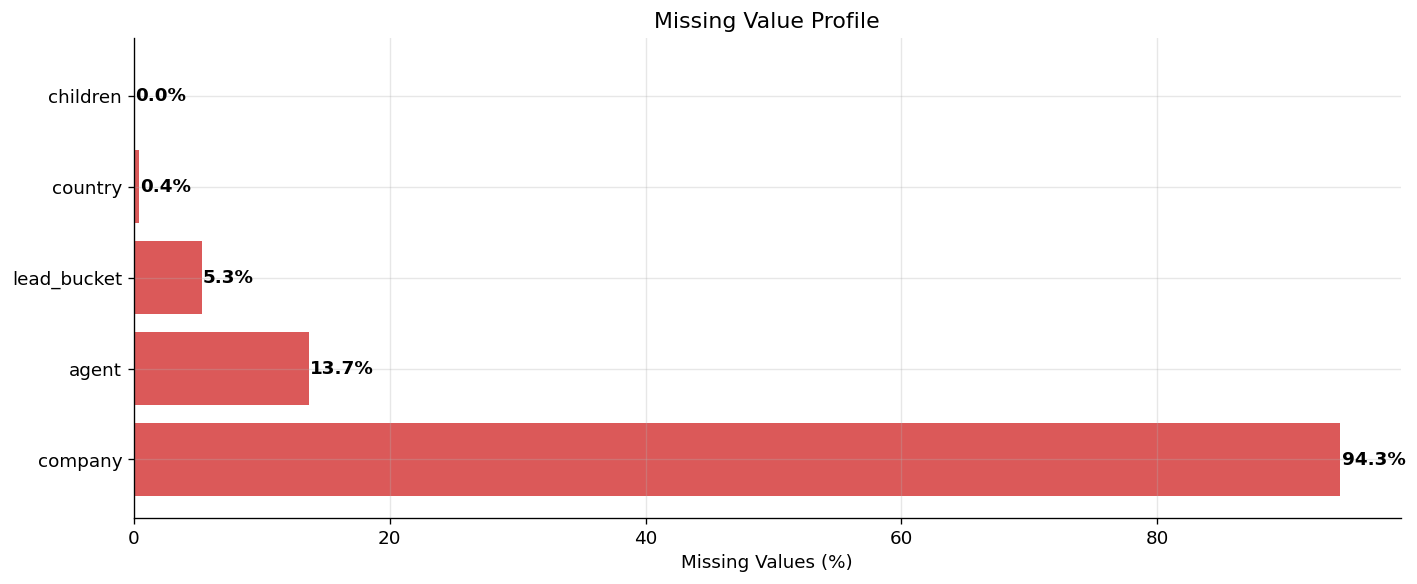

In [41]:
# Missing Value Analysis
fig, ax = plt.subplots(figsize=(12, 5))

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pct_missing = (missing / len(df) * 100).round(2)

bars = ax.barh(missing.index, pct_missing.values, color=RED, alpha=0.8)
ax.set_xlabel("Missing Values (%)")
ax.set_title("Missing Value Profile")
for bar, v in zip(bars, pct_missing.values):
    ax.text(v + 0.1, bar.get_y() + bar.get_height()/2,
            f"{v:.1f}%", va="center", fontweight="bold")

plt.tight_layout()


print("Missing :")
print(missing.to_string())

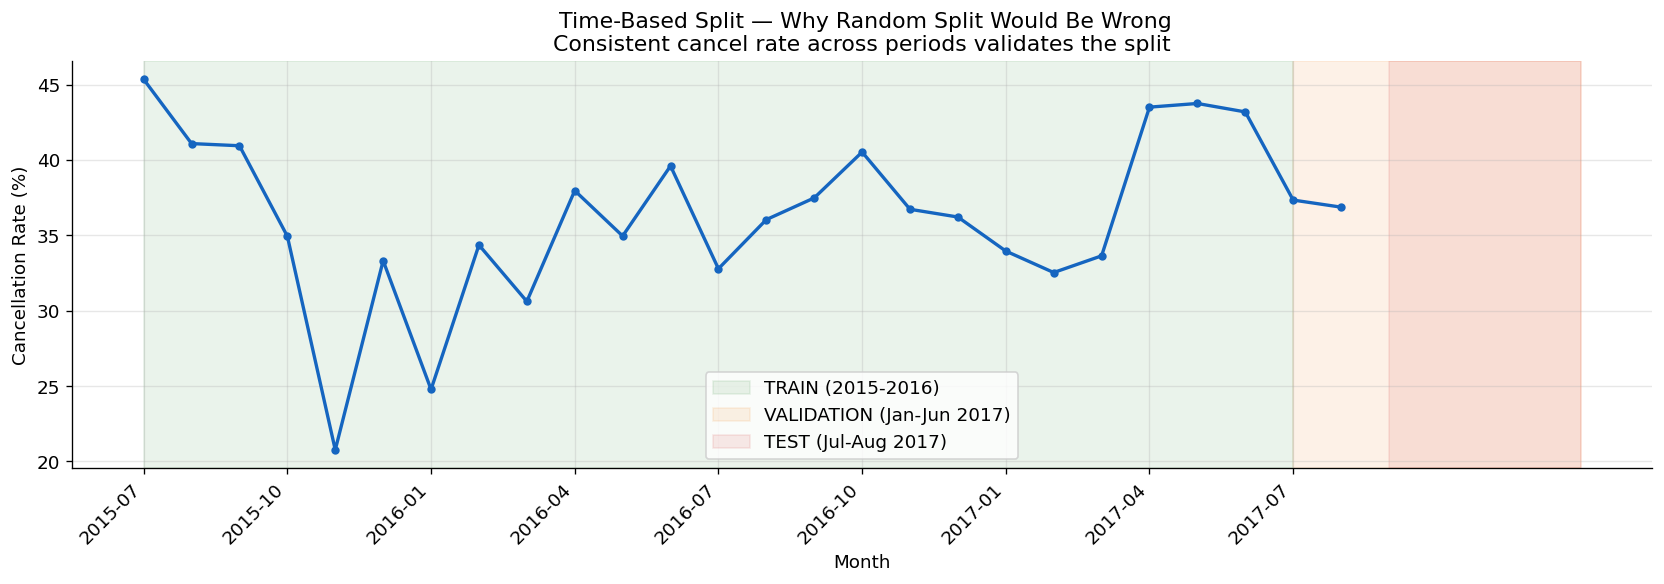

In [42]:

# Time-Based Split Validation
month_map = {"January": 1, "February": 2, "March": 3, "April": 4,
             "May": 5, "June": 6, "July": 7, "August": 8,
             "September": 9, "October": 10, "November": 11, "December": 12}
df["month_num"] = df["arrival_date_month"].map(month_map)
df["period"] = df["arrival_date_year"].astype(str) + "-" + df["month_num"].astype(str).str.zfill(2)
df_sorted = df.sort_values("period")

# Cancel rate over time
cancel_over_time = df_sorted.groupby("period")["is_canceled"].mean() * 100

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(cancel_over_time))
ax.plot(x, cancel_over_time.values, color=BLUE, lw=2, marker="o", ms=4)
ax.axvspan(0, 24, alpha=0.1, color=GREEN, label="TRAIN (2015-2016)")
ax.axvspan(24, 30, alpha=0.1, color=AMBER, label="VALIDATION (Jan-Jun 2017)")
ax.axvspan(30, len(x), alpha=0.1, color=RED, label="TEST (Jul-Aug 2017)")
ax.set_xlabel("Month")
ax.set_ylabel("Cancellation Rate (%)")
ax.set_xticks(list(x)[::3])
ax.set_xticklabels(list(cancel_over_time.index)[::3], rotation=45, ha="right")
ax.set_title(" Time-Based Split — Why Random Split Would Be Wrong\n"
             "Consistent cancel rate across periods validates the split")
ax.legend()
plt.tight_layout()


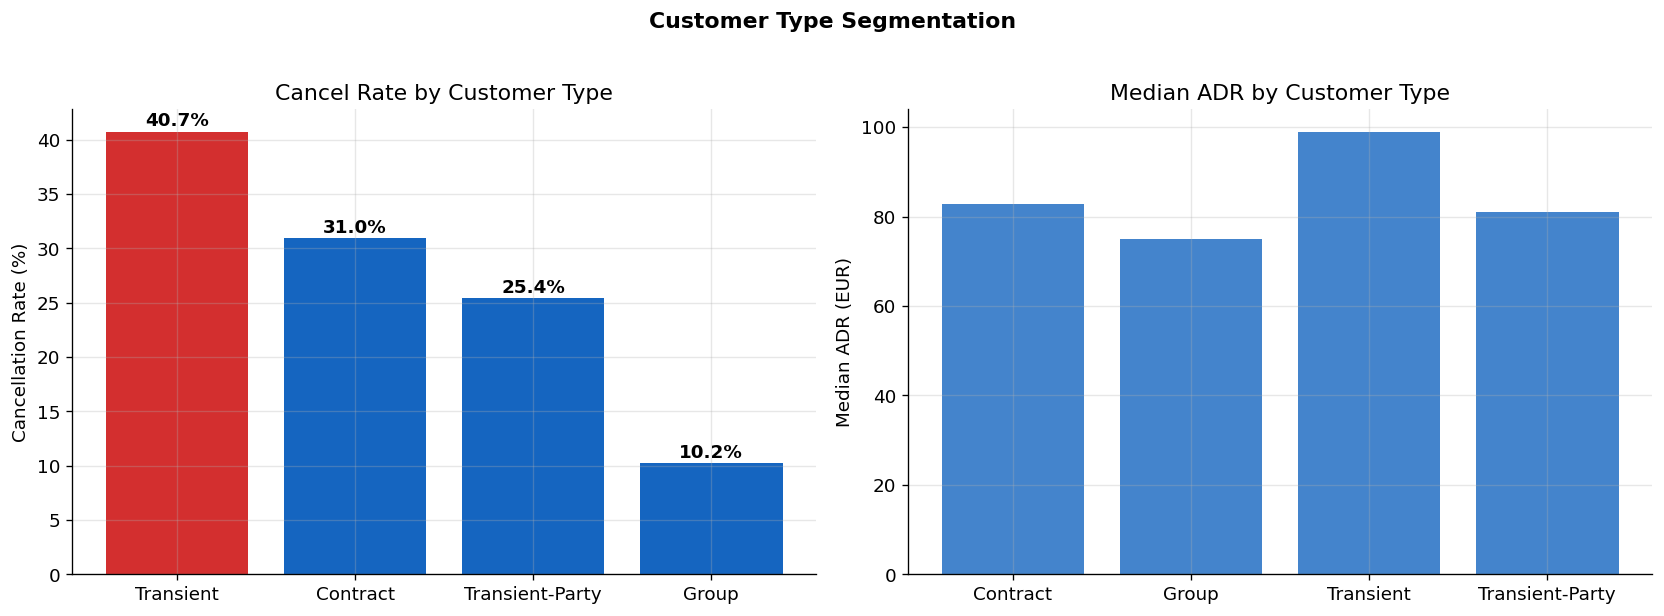

In [43]:
#  Customer Type Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cancel_by_customer = df.groupby("customer_type")["is_canceled"].mean() * 100
cancel_by_customer = cancel_by_customer.sort_values(ascending=False)
axes[0].bar(cancel_by_customer.index, cancel_by_customer.values,
            color=[RED if v > 40 else BLUE for v in cancel_by_customer.values])
axes[0].set_ylabel("Cancellation Rate (%)")
axes[0].set_title("Cancel Rate by Customer Type")
for i, v in enumerate(cancel_by_customer.values):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

adr_by_customer = df.groupby("customer_type")["adr"].median()
axes[1].bar(adr_by_customer.index, adr_by_customer.values, color=BLUE, alpha=0.8)
axes[1].set_ylabel("Median ADR (EUR)")
axes[1].set_title("Median ADR by Customer Type")

plt.suptitle("Customer Type Segmentation", fontweight="bold", y=1.02)
plt.tight_layout()


TOP CORRELATIONS with is_canceled:
lead_time                         0.293123
total_of_special_requests         0.234658
required_car_parking_spaces       0.195498
booking_changes                   0.144381
previous_cancellations            0.110133
adults                            0.060017
previous_bookings_not_canceled    0.057358
days_in_waiting_list              0.054186
Name: is_canceled, dtype: float64


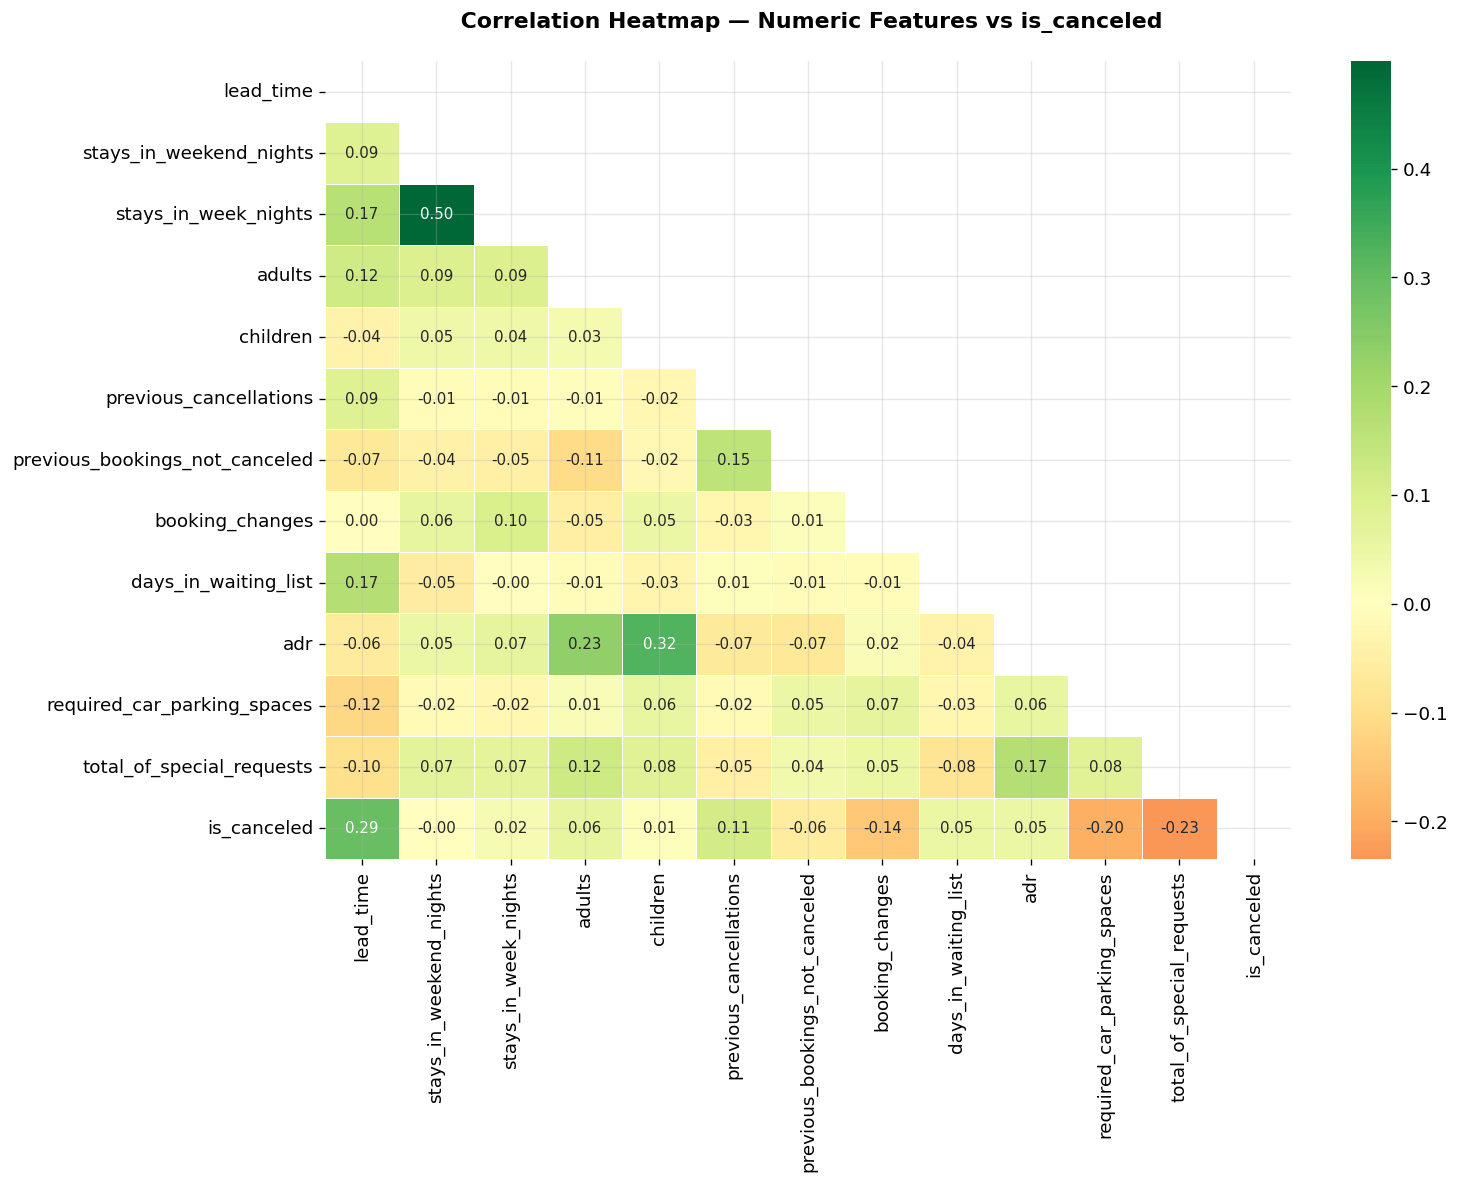

In [44]:
#  Correlation Heatmap
numeric_cols = ["lead_time", "stays_in_weekend_nights", "stays_in_week_nights",
                "adults", "children", "previous_cancellations",
                "previous_bookings_not_canceled", "booking_changes",
                "days_in_waiting_list", "adr",
                "required_car_parking_spaces", "total_of_special_requests",
                "is_canceled"]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=ax, linewidths=0.5,
            annot_kws={"size": 9})
ax.set_title(" Correlation Heatmap — Numeric Features vs is_canceled",
             fontweight="bold", pad=20)
plt.tight_layout()


print("TOP CORRELATIONS with is_canceled:")
print(corr["is_canceled"].drop("is_canceled").abs().sort_values(ascending=False).head(8))



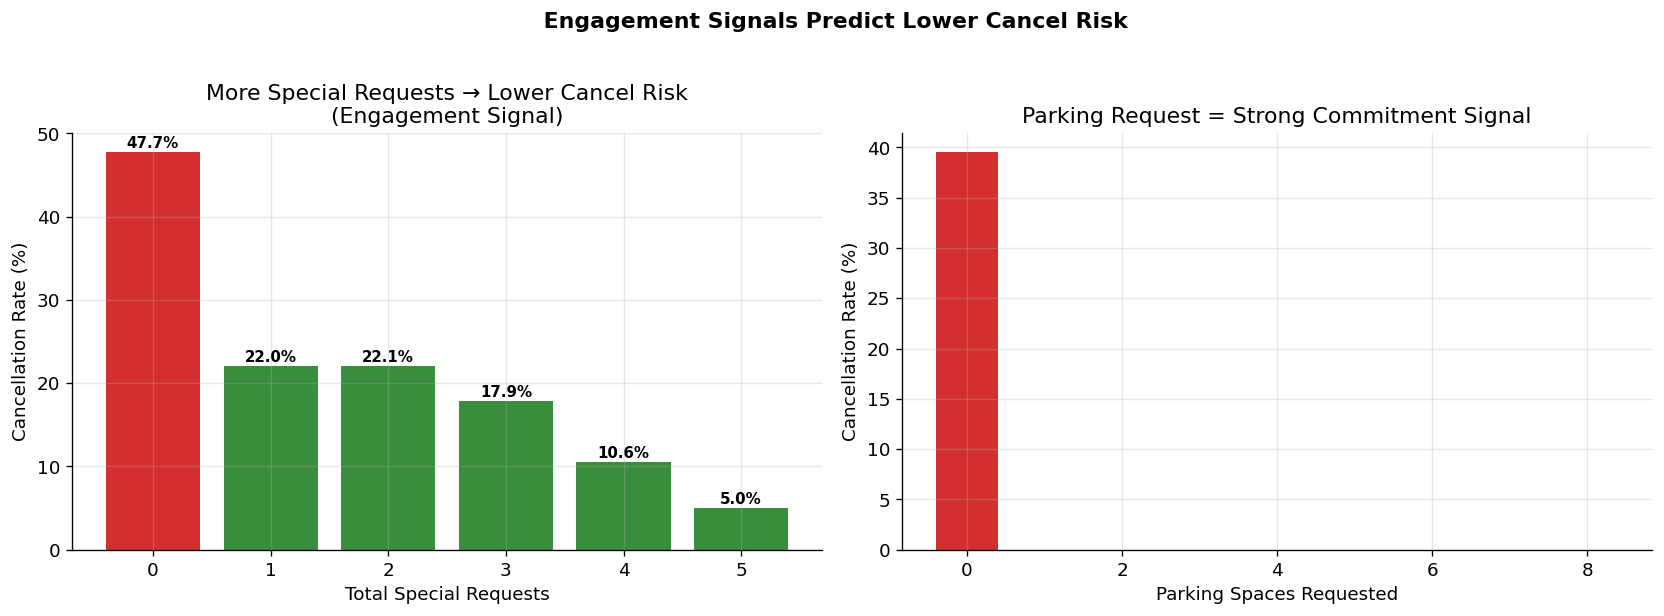

In [45]:
#  Special Requests vs Cancel Rate

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cancel_by_requests = df.groupby("total_of_special_requests")["is_canceled"].mean() * 100
axes[0].bar(cancel_by_requests.index, cancel_by_requests.values,
            color=[GREEN if v < 30 else RED for v in cancel_by_requests.values])
axes[0].set_xlabel("Total Special Requests")
axes[0].set_ylabel("Cancellation Rate (%)")
axes[0].set_title("More Special Requests → Lower Cancel Risk\n(Engagement Signal)")
for i, v in zip(cancel_by_requests.index, cancel_by_requests.values):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold", fontsize=9)

cancel_by_parking = df.groupby("required_car_parking_spaces")["is_canceled"].mean() * 100
axes[1].bar(cancel_by_parking.index, cancel_by_parking.values,
            color=[GREEN if v < 30 else RED for v in cancel_by_parking.values])
axes[1].set_xlabel("Parking Spaces Requested")
axes[1].set_ylabel("Cancellation Rate (%)")
axes[1].set_title("Parking Request = Strong Commitment Signal")

plt.suptitle(" Engagement Signals Predict Lower Cancel Risk", fontweight="bold", y=1.02)
plt.tight_layout()

  

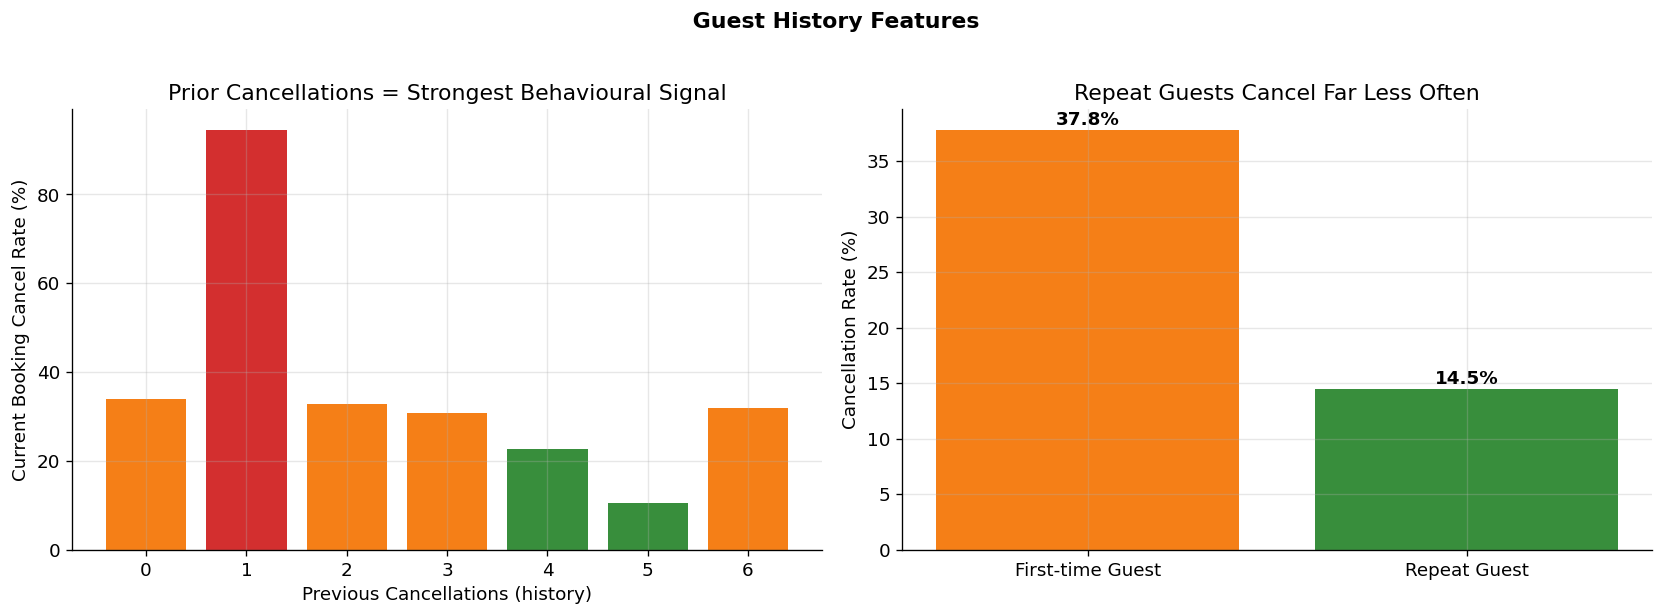

In [46]:
#  Previous Cancellations History

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_prev = df[df["previous_cancellations"] <= 10]
cancel_by_prev = df_prev.groupby("previous_cancellations")["is_canceled"].mean() * 100
axes[0].bar(cancel_by_prev.index, cancel_by_prev.values,
            color=[RED if v > 50 else AMBER if v > 30 else GREEN for v in cancel_by_prev.values])
axes[0].set_xlabel("Previous Cancellations (history)")
axes[0].set_ylabel("Current Booking Cancel Rate (%)")
axes[0].set_title("Prior Cancellations = Strongest Behavioural Signal")

is_repeated = df.groupby("is_repeated_guest")["is_canceled"].mean() * 100
axes[1].bar(["First-time Guest", "Repeat Guest"],
            [is_repeated.get(0, 0), is_repeated.get(1, 0)],
            color=[AMBER, GREEN])
axes[1].set_ylabel("Cancellation Rate (%)")
axes[1].set_title("Repeat Guests Cancel Far Less Often")
for i, v in enumerate([is_repeated.get(0, 0), is_repeated.get(1, 0)]):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

plt.suptitle(" Guest History Features", fontweight="bold", y=1.02)
plt.tight_layout()


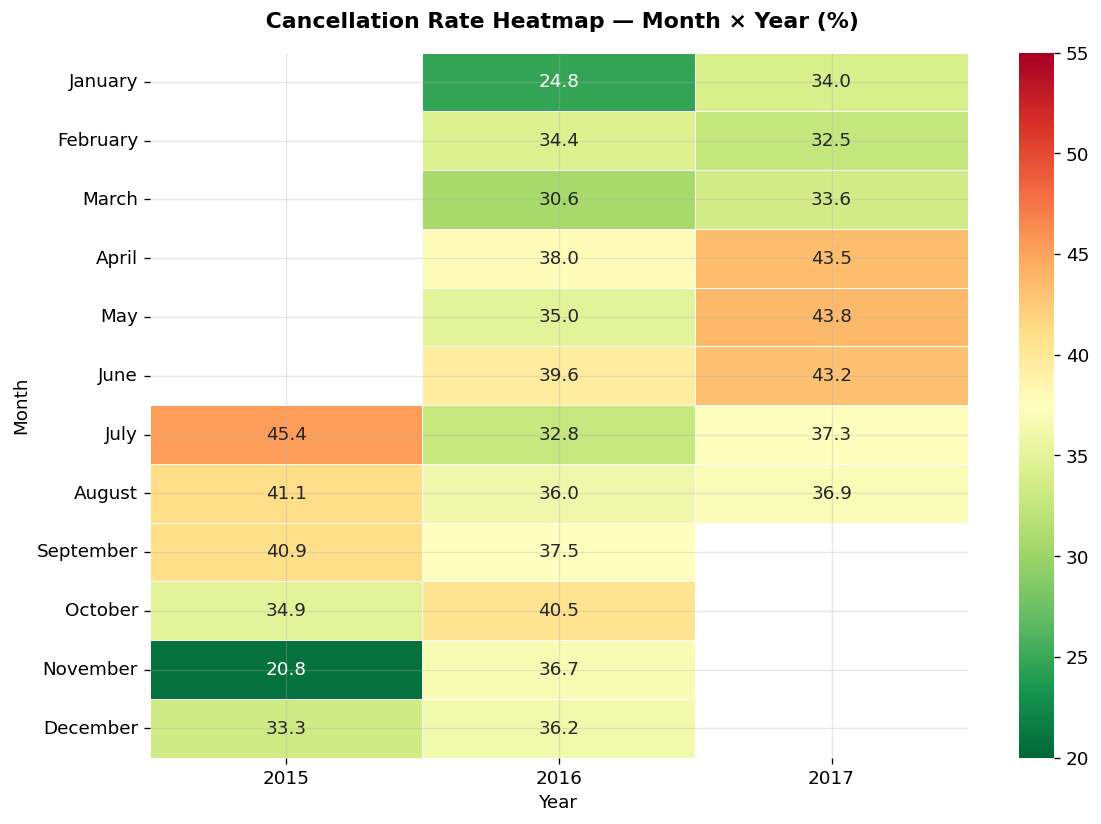

In [47]:
#  Seasonality Heatmap
pivot = df.pivot_table(
    values="is_canceled", index="arrival_date_month",
    columns="arrival_date_year", aggfunc="mean"
).reindex(list(month_map.keys())) * 100

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn_r",
            linewidths=0.5, ax=ax, vmin=20, vmax=55)
ax.set_title(" Cancellation Rate Heatmap — Month × Year (%)",
             fontweight="bold", pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Month")
plt.tight_layout()


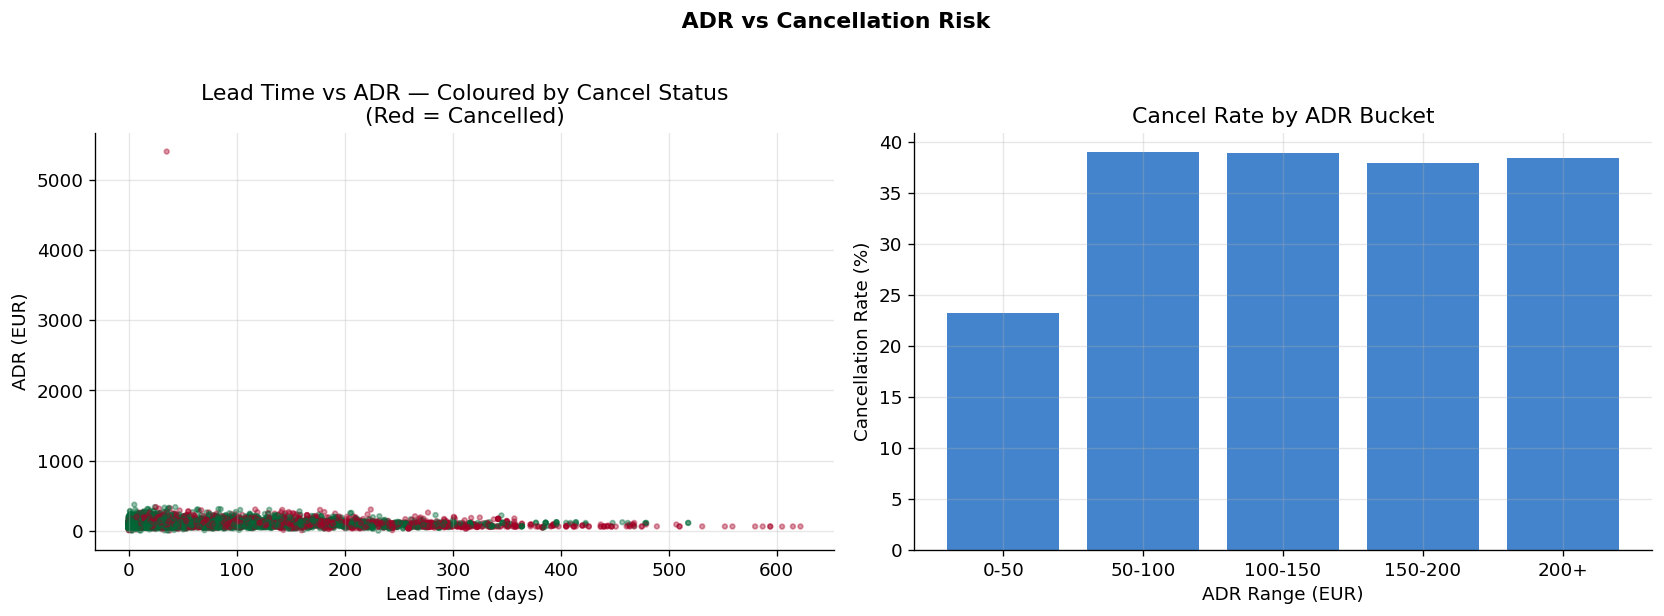

In [48]:
# ADR vs Cancel Probability (Scatter)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = df[df["adr"] > 0].sample(5000, random_state=42)
axes[0].scatter(sample["lead_time"], sample["adr"],
                c=sample["is_canceled"], cmap="RdYlGn_r",
                alpha=0.4, s=8)
axes[0].set_xlabel("Lead Time (days)")
axes[0].set_ylabel("ADR (EUR)")
axes[0].set_title("Lead Time vs ADR — Coloured by Cancel Status\n(Red = Cancelled)")

adr_buckets = pd.cut(df["adr"], bins=[0, 50, 100, 150, 200, 5000],
                     labels=["0-50", "50-100", "100-150", "150-200", "200+"])
cancel_by_adr = df.groupby(adr_buckets)["is_canceled"].mean() * 100
axes[1].bar(cancel_by_adr.index.astype(str), cancel_by_adr.values, color=BLUE, alpha=0.8)
axes[1].set_xlabel("ADR Range (EUR)")
axes[1].set_ylabel("Cancellation Rate (%)")
axes[1].set_title("Cancel Rate by ADR Bucket")

plt.suptitle(" ADR vs Cancellation Risk", fontweight="bold", y=1.02)
plt.tight_layout()





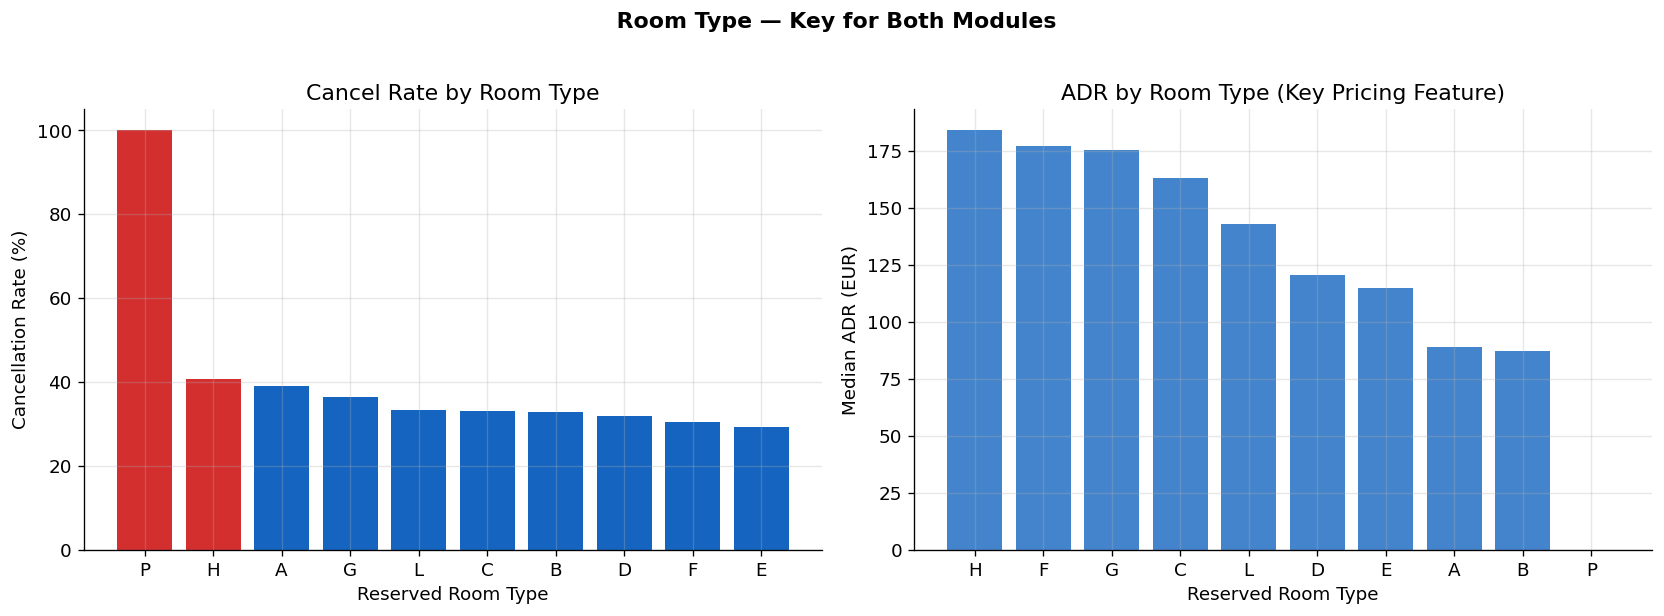

In [49]:
#  Room Type Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

room_cancel = df.groupby("reserved_room_type")["is_canceled"].mean() * 100
room_cancel = room_cancel.sort_values(ascending=False)
axes[0].bar(room_cancel.index, room_cancel.values,
            color=[RED if v > 40 else BLUE for v in room_cancel.values])
axes[0].set_xlabel("Reserved Room Type")
axes[0].set_ylabel("Cancellation Rate (%)")
axes[0].set_title("Cancel Rate by Room Type")

room_adr = df.groupby("reserved_room_type")["adr"].median().sort_values(ascending=False)
axes[1].bar(room_adr.index, room_adr.values, color=BLUE, alpha=0.8)
axes[1].set_xlabel("Reserved Room Type")
axes[1].set_ylabel("Median ADR (EUR)")
axes[1].set_title("ADR by Room Type (Key Pricing Feature)")

plt.suptitle(" Room Type — Key for Both Modules", fontweight="bold", y=1.02)
plt.tight_layout()


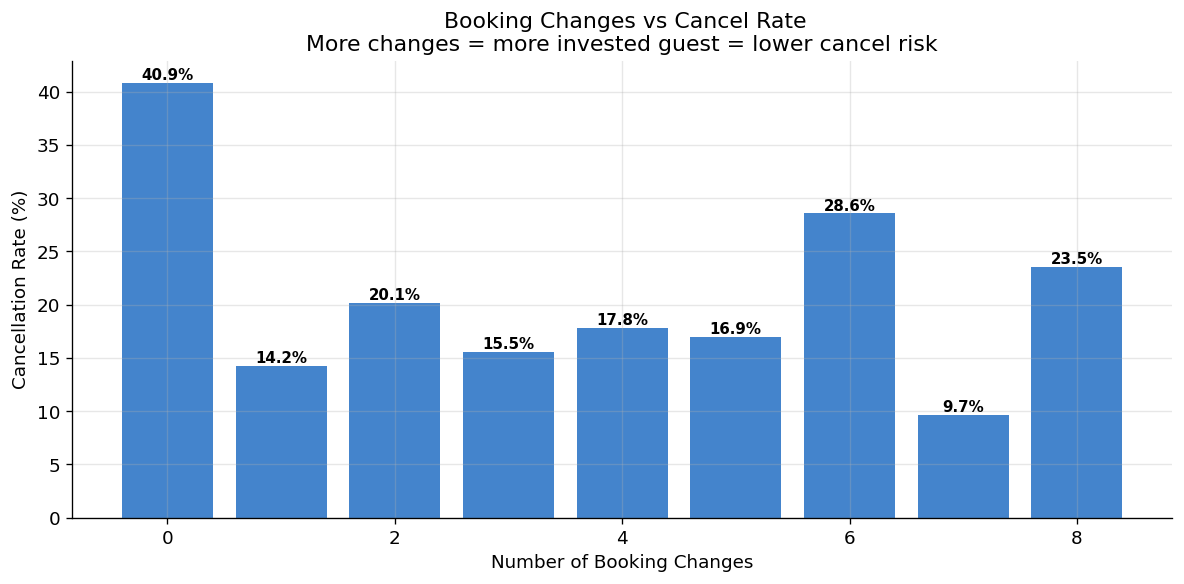

In [50]:
# Booking Changes

fig, ax = plt.subplots(figsize=(10, 5))
df_changes = df[df["booking_changes"] <= 8]
cancel_by_changes = df_changes.groupby("booking_changes")["is_canceled"].mean() * 100
ax.bar(cancel_by_changes.index, cancel_by_changes.values, color=BLUE, alpha=0.8)
ax.set_xlabel("Number of Booking Changes")
ax.set_ylabel("Cancellation Rate (%)")
ax.set_title(" Booking Changes vs Cancel Rate\n"
             "More changes = more invested guest = lower cancel risk")
for i, v in zip(cancel_by_changes.index, cancel_by_changes.values):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontweight="bold", fontsize=9)
plt.tight_layout()





In [51]:
# Data Quality Summary Report

print("=" * 70)
print("COMPLETE DATA QUALITY FINDINGS SUMMARY")
print("=" * 70)

findings = {
    "Duplicate rows": df.duplicated().sum(),
    "Zero-guest bookings": ((df["adults"] == 0) & (df["children"] == 0) & (df["babies"] == 0)).sum(),
    "Negative ADR rows": (df["adr"] < 0).sum(),
    "ADR = 0 rows (free rooms)": (df["adr"] == 0).sum(),
    "Extreme ADR > 5000": (df["adr"] > 5000).sum(),
    "Missing children": df["children"].isna().sum(),
    "Missing country": df["country"].isna().sum(),
    "Missing agent": df["agent"].isna().sum(),
    "Missing company": df["company"].isna().sum(),
}
for k, v in findings.items():
    print(f"  {k:<40}: {v:>6,}")

print("\n" + "=" * 70)
print("LEAKAGE COLUMNS TO DROP BEFORE ANY MODELLING:")
print("  1. reservation_status       (encodes is_canceled directly)")
print("  2. reservation_status_date  (the date of the status = after the fact)")
print("=" * 70)

print("\nFEATURE ENGINEERING OPPORTUNITIES IDENTIFIED:")
for feat, reason in [
    ("cancel_rate_history", "previous_cancellations / total_previous — guest history"),
    ("total_guests", "adults + children + 0.5*babies — booking value proxy"),
    ("total_nights", "weekend + weekday — commitment signal"),
    ("lead_time_bucket", "non-linear cancel risk by lead time band"),
    ("booking_month_sin/cos", "cyclical month encoding — preserves Jan/Dec adjacency"),
    ("room_mismatch", "reserved != assigned — dissatisfaction risk"),
    ("deposit_risk_score", "numeric encoding of deposit type risk level"),
    ("channel_premium", "distribution channel pricing tier"),
]:
    print(f"  ✓ {feat:<30} | {reason}")

COMPLETE DATA QUALITY FINDINGS SUMMARY
  Duplicate rows                          : 31,994
  Zero-guest bookings                     :    180
  Negative ADR rows                       :      1
  ADR = 0 rows (free rooms)               :  1,959
  Extreme ADR > 5000                      :      1
  Missing children                        :      4
  Missing country                         :    488
  Missing agent                           : 16,340
  Missing company                         : 112,593

LEAKAGE COLUMNS TO DROP BEFORE ANY MODELLING:
  1. reservation_status       (encodes is_canceled directly)
  2. reservation_status_date  (the date of the status = after the fact)

FEATURE ENGINEERING OPPORTUNITIES IDENTIFIED:
  ✓ cancel_rate_history            | previous_cancellations / total_previous — guest history
  ✓ total_guests                   | adults + children + 0.5*babies — booking value proxy
  ✓ total_nights                   | weekend + weekday — commitment signal
  ✓ lead_time_bu